# Resolución de MKP usando PSO


## Carga de Archivos

Importación de librerías a usar

In [1]:
import requests
import numpy as np
import matplotlib.pyplot as plt
import random
from sklearn.linear_model import LinearRegression

Bajada de archivos de MKP, se puede cambiar la URL mediante parámetro.


In [2]:
import requests

url = "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb1.txt" # @param ["http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknap1.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb1.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb1.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb2.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb3.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb4.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb5.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb6.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb7.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb8.txt", "http://people.brunel.ac.uk/~mastjjb/jeb/orlib/files/mknapcb9.txt"] {allow-input: true}

try:
    response = requests.get(url)
    response.raise_for_status()  # Verifica si la solicitud fue exitosa
    text_content = response.text

    # Ahora, text_content contiene el texto del archivo en la URL
    print("Instancia cargada con éxito.")

    # Puedes imprimir o hacer lo que necesites con el texto

except requests.exceptions.RequestException as e:
    print(f"Error al obtener el contenido desde la URL: {e}")


Instancia cargada con éxito.


Función que parsea la url para extraer en una lista las instancias del mkp presentes en el archivo

In [3]:
def cargar_instancia_mkp(cadena):
  # Lista de instancias del problema
  instancias = []


  # Dividir la cadena en líneas y luego en números
  lineas = cadena.strip().split('\n')
  numeros = [list(map(float, linea.split())) for linea in lineas]

  #Lector de archivo
  linea_actual = 0

  # Extraer la cantidad de instancias que contiene el archivo
  n_instancias = int(numeros[linea_actual][0])


  for _ in range(n_instancias):

    # Esto es para que se salte la linea vacía que hay entre instancias
    linea_actual += 1
    if numeros[linea_actual] == [] :
      linea_actual += 1

    # Extraer n, m, y el valor de la solución óptima
    n, m, valor_optimo = numeros[linea_actual]
    n, m = [int(n), int(m)]

    linea_actual += 1

    p = []

    while (len(p)<n):
      p += numeros[linea_actual]
      linea_actual += 1

    # Inicializar una lista vacía para las restricciones y los lados derechos
    r = []
    b = []

    # Extraer los coeficientes de las restricciones r(i,j) y b(i)
    for i in range(m):
      new_restriction = []
      while(len(new_restriction) < n):
        new_restriction = new_restriction + numeros[linea_actual]
        linea_actual += 1
      r.append(new_restriction)  # Agregar la nueva lista a r

    while (len(b) < m):
      b += numeros[linea_actual]
      linea_actual += 1
    linea_actual -= 1

    p = np.array(p)
    r = np.array(r)
    b = np.array(b)

    instancias.append({"n": n, "m": m, "valor_optimo": valor_optimo, "p": p, "r": r, "b": b})

  return instancias

instancias = cargar_instancia_mkp(text_content)

data = random.choice(instancias)



In [4]:
data = instancias[9]

In [5]:
data

{'n': 100,
 'm': 5,
 'valor_optimo': 0.0,
 'p': array([ 720.,  569.,  832.,  746.,  601.,  863.,  596., 1013.,  736.,
         737., 1062.,  381., 1044.,  605.,  970., 1177.,  747.,  842.,
         875.,  627.,  839.,  674.,  897.,  876.,  597.,  649., 1087.,
         752.,  525.,  754.,  692.,  835.,  436., 1183.,  369.,  940.,
         654., 1090.,  780., 1045.,  578.,  896., 1008.,  798.,  734.,
         987.,  694.,  565.,  809.,  818.,  972.,  887.,  614.,  930.,
         694.,  872.,  712.,  500.,  739.,  831.,  522., 1008.,  834.,
         734.,  490.,  924.,  422.,  598.,  499.,  846.,  939.,  797.,
         538.,  656.,  931.,  861.,  784.,  586.,  859.,  620., 1055.,
         645.,  857.,  623.,  797.,  643.,  566.,  811.,  819.,  688.,
         922., 1142.,  902.,  795.,  744.,  754.,  453.,  427.,  839.,
         928.]),
 'r': array([[921., 367., 638., 810., 166., 650., 365., 974., 685., 545., 962.,
         439.,  12., 618., 255., 835., 790., 963., 111., 200., 999., 117.,


In [6]:
n = data['n']  # Número de elementos
m = data['m']  # Número de mochilas
valor_optimo = data['valor_optimo']  # Valor óptimo conocido
p = data['p']  # Coeficientes de valor de los elementos
r = data['r']  # Restricciones de capacidad de las mochilas
b = data['b']  # Lado derecho de las restricciones

density_per_bag = [p / r[i] for i in range(m)]

density_per_bag = np.array(density_per_bag)

# Encontrar el valor máximo entre los elementos finitos
finite_max = np.max(density_per_bag[np.isfinite(density_per_bag)])

# Reemplazar los valores infinitos con el valor máximo encontrado * 10
density_per_bag[np.isinf(density_per_bag)] = finite_max * 10

density = np.min(density_per_bag, axis=0)

# Obtener los índices en orden ascendente
indices_ascendentes = np.argsort(density)

# Función de reparación modificada para usar índices y orden precalculados
def reparar_solucion(solucion, p, r, b, density):
  for i in range(len(solucion)):
    aux = solucion.copy()
    aux[int(indices_ascendentes[i])] = 0
    if not np.all(np.dot(aux, r.T) <= b):
      solucion = aux
    else:
      solucion = aux
      break

  for i in range(len(solucion)):
    aux = solucion.copy()
    aux[int(indices_ascendentes[i])] = 1
    if np.all(np.dot(aux, r.T) <= b):
      solucion = aux
    else:
      break

  valor_total = np.sum(solucion * p)
  return solucion, valor_total

In [7]:
print(n,m,p,r,b, valor_optimo)

100 5 [ 720.  569.  832.  746.  601.  863.  596. 1013.  736.  737. 1062.  381.
 1044.  605.  970. 1177.  747.  842.  875.  627.  839.  674.  897.  876.
  597.  649. 1087.  752.  525.  754.  692.  835.  436. 1183.  369.  940.
  654. 1090.  780. 1045.  578.  896. 1008.  798.  734.  987.  694.  565.
  809.  818.  972.  887.  614.  930.  694.  872.  712.  500.  739.  831.
  522. 1008.  834.  734.  490.  924.  422.  598.  499.  846.  939.  797.
  538.  656.  931.  861.  784.  586.  859.  620. 1055.  645.  857.  623.
  797.  643.  566.  811.  819.  688.  922. 1142.  902.  795.  744.  754.
  453.  427.  839.  928.] [[921. 367. 638. 810. 166. 650. 365. 974. 685. 545. 962. 439.  12. 618.
  255. 835. 790. 963. 111. 200. 999. 117. 615. 718. 297. 399. 998. 579.
  337. 977. 828. 332. 769. 743. 595. 452.  12. 577. 128. 535.  60. 973.
  808. 763. 915. 492. 578. 699. 171. 796. 393. 562. 798. 515.  22. 282.
  549. 430. 639. 802. 145. 348. 865. 377. 658. 663.  95. 341.   3. 508.
  912. 786. 946.  62. 59

# DTW

In [8]:
%%writefile dtw_stagnation.py
from __future__ import annotations
from dataclasses import dataclass, field
from typing import List, Dict, Optional
import numpy as np

def dtw_distance(s: np.ndarray, t: np.ndarray, window: Optional[int] = None) -> float:
    s = np.asarray(s, dtype=float); t = np.asarray(t, dtype=float)
    n, m = len(s), len(t)
    if window is None: window = max(n, m)
    window = max(window, abs(n - m))
    INF = float('inf')
    D = np.full((n + 1, m + 1), INF); D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_start = max(1, i - window); j_end = min(m, i + window); si = s[i-1]
        for j in range(j_start, j_end + 1):
            cost = abs(si - t[j-1])
            D[i, j] = cost + min(D[i-1, j], D[i, j-1], D[i-1, j-1])
    return float(D[n, m])

def first_diff(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float); return np.diff(x, prepend=x[0])

def ddtw_distance(s: np.ndarray, t: np.ndarray, window: Optional[int] = None) -> float:
    return dtw_distance(first_diff(s), first_diff(t), window=window)

def ramp_baseline(start_value: float, s_min: float, length: int) -> np.ndarray:
    i = np.arange(length, dtype=float); return start_value + s_min * i

def constant_baseline(start_value: float, length: int) -> np.ndarray:
    return np.full(length, float(start_value))

def moving_percentile(buffer: List[float], p: float) -> float:
    arr = np.asarray(buffer, dtype=float)
    return float(np.percentile(arr, p)) if arr.size > 0 else float('nan')

@dataclass
class StagnationConfig:
    window: int = 30
    band: int = 0            # si 0 -> 10% de window
    min_slope: float = 0.0
    plateau_max: int = 15
    patience: int = 3
    use_ddtw: bool = False
    adapt_thresholds: bool = True
    p_low: float = 30.0
    p_high: float = 70.0
    def __post_init__(self):
        if self.band <= 0: self.band = max(1, int(0.1 * self.window))

@dataclass
class StagnationMonitor:
    cfg: StagnationConfig
    best_so_far: List[float] = field(default_factory=list)
    no_improve_len: int = 0
    trigger_streak: int = 0
    d1_hist: List[float] = field(default_factory=list)
    d2_hist: List[float] = field(default_factory=list)
    delta_hist: List[float] = field(default_factory=list)

    def update(self, new_best: float):
            # --- Sanitize: convertir a escalar float ---
        if isinstance(new_best, (list, tuple, np.ndarray)):
            arr = np.asarray(new_best, dtype=float)
            # política: usamos el máximo porque el best-so-far es de maximización
            new_best = float(np.max(arr))
        else:
            new_best = float(new_best)

        # si por error se guardó algo no escalar antes, lo reparamos
        if self.best_so_far and isinstance(self.best_so_far[-1], (list, tuple, np.ndarray)):
            self.best_so_far = [float(np.max(np.asarray(v, dtype=float))) for v in self.best_so_far]

        if self.best_so_far and new_best <= self.best_so_far[-1]:
            self.no_improve_len += 1; new_best = self.best_so_far[-1]
        else:
            self.no_improve_len = 0
        self.best_so_far.append(float(new_best))

        n = len(self.best_so_far); W = self.cfg.window
        if n < W:
            return {'ready': False, 'fire': False, 'no_improve_len': self.no_improve_len, 'n': n}

        X = np.array(self.best_so_far[-W:], dtype=float)
        start = X[0]

        s_min = self.cfg.min_slope
        if s_min == 0.0:
            rng = max(1.0, abs(X[-1] - X[0])); s_min = 0.01 * rng / W

        r = ramp_baseline(start, s_min, W); c = constant_baseline(start, W)

        if self.cfg.use_ddtw:
            D1 = ddtw_distance(X, r, window=self.cfg.band); D2 = ddtw_distance(X, c, window=self.cfg.band)
        else:
            D1 = dtw_distance(X, r, window=self.cfg.band); D2 = dtw_distance(X, c, window=self.cfg.band)

        delta = D1 - D2
        self.d1_hist.append(D1); self.d2_hist.append(D2); self.delta_hist.append(delta)

        if self.cfg.adapt_thresholds and len(self.d1_hist) >= 10:
            theta_c = moving_percentile(self.d2_hist, self.cfg.p_low)
            theta_r = moving_percentile(self.d1_hist, self.cfg.p_high)
            theta_delta = moving_percentile(self.delta_hist, self.cfg.p_high)
        else:
            theta_c = 0.1 * W; theta_r = 0.5 * W; theta_delta = 0.3 * W

        cond_plateau = (self.no_improve_len >= self.cfg.plateau_max)
        cond_constant = (D2 <= theta_c)
        cond_ramp = (D1 >= theta_r) or (delta >= theta_delta)

        if cond_plateau and cond_constant and cond_ramp:
            self.trigger_streak += 1
        else:
            self.trigger_streak = 0

        fire = self.trigger_streak >= self.cfg.patience
        return {'ready': True, 'fire': bool(fire),
                'D1_vs_ramp': float(D1), 'D2_vs_const': float(D2), 'delta': float(delta),
                'theta_c': float(theta_c), 'theta_r': float(theta_r), 'theta_delta': float(theta_delta),
                'no_improve_len': int(self.no_improve_len), 'trigger_streak': int(self.trigger_streak), 'n': int(n)}


Writing dtw_stagnation.py


In [9]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

best = [0,2,2,2,3,3,8,8,8,8,10,10,10,11,11,11,11,11,12]
mon = StagnationMonitor(StagnationConfig(window=10, plateau_max=4, patience=2))
for t,v in enumerate(best,1):
    out = mon.update(v)
    if out.get('ready'):
        print(f"t={t:02d} fire={out['fire']} no_improve={out['no_improve_len']}"
              f" D1={out['D1_vs_ramp']:.1f} D2={out['D2_vs_const']:.1f} Δ={out['delta']:.1f}")


t=10 fire=False no_improve=3 D1=43.6 D2=44.0 Δ=-0.4
t=11 fire=False no_improve=0 D1=33.7 D2=34.0 Δ=-0.3
t=12 fire=False no_improve=1 D1=41.6 D2=42.0 Δ=-0.4
t=13 fire=False no_improve=2 D1=49.6 D2=50.0 Δ=-0.4
t=14 fire=False no_improve=0 D1=48.6 D2=49.0 Δ=-0.4
t=15 fire=False no_improve=1 D1=56.6 D2=57.0 Δ=-0.4
t=16 fire=False no_improve=2 D1=14.9 D2=15.0 Δ=-0.1
t=17 fire=False no_improve=3 D1=17.9 D2=18.0 Δ=-0.1
t=18 fire=False no_improve=4 D1=20.9 D2=21.0 Δ=-0.1
t=19 fire=False no_improve=0 D1=24.8 D2=25.0 Δ=-0.2


In [10]:
# Parámetros del PSO
num_particulas = 20
num_iteraciones = 100
inercia = (0.9 + 0.4)/2
coeficiente_cognitivo = 2
coeficiente_social = 2
epoch = 10

In [11]:
# Parámetros de binarización
V_max = 8

G1_i = 0.5
G1_f = 1

G2_i = 0.5
G2_f = 0.9*V_max

G3_i = 0.5
G3_f = 0

In [12]:
results_original = []
results_version1 = []
results_version2 = []
results_version3 = []
results_version4 = []
results_version5 = []
results_version6 = []
results_version7 = []
results_version8 = []

# Original

Comienzo Epoch 1
iter=019 n=20 D1=471.000 D2=441.000 Δ=30.000 θc=2.00 θr=10.00 no_improve=10 fire=False best=22106.0
iter=020 n=21 D1=471.000 D2=441.000 Δ=30.000 θc=2.00 θr=10.00 no_improve=11 fire=False best=22106.0
iter=021 n=22 D1=729.000 D2=703.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=0 fire=False best=22368.0
iter=022 n=23 D1=729.000 D2=703.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=1 fire=False best=22368.0
iter=023 n=24 D1=729.000 D2=703.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=2 fire=False best=22368.0
iter=024 n=25 D1=955.000 D2=929.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=0 fire=False best=22636.0
iter=025 n=26 D1=955.000 D2=929.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=1 fire=False best=22636.0
iter=026 n=27 D1=955.000 D2=929.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=2 fire=False best=22636.0
iter=027 n=28 D1=955.000 D2=929.000 Δ=26.000 θc=2.00 θr=10.00 no_improve=3 fire=False best=22636.0
iter=028 n=29 D1=560.000 D2=530.000 Δ=30.000 θc=2.00 θr=10.00 no_improve=4 fire=False best

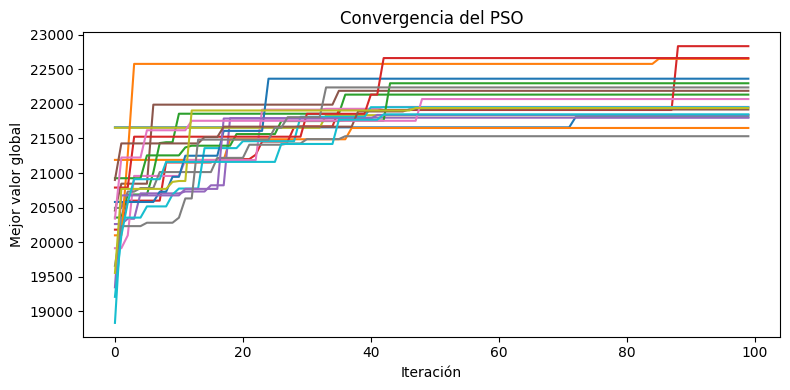

In [13]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

#original
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")

  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=False  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    if out.get("ready"):
      print(
          f"iter={iteracion:03d}",
          f"n={out['n']}",
          f"D1={out['D1_vs_ramp']:.3f}",
          f"D2={out['D2_vs_const']:.3f}",
          f"Δ={out['delta']:.3f}",
          f"θc={out['theta_c']:.2f}",
          f"θr={out['theta_r']:.2f}",
          f"no_improve={out['no_improve_len']}",
          f"fire={out['fire']}",
          f"best={mejor_valor_global:.1f}"
      )

  results_original.append(mejor_valor_global)
  print(f"Fin Epoch {aux + 1}")

print(results_original)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

# Versiones

### Version original - MH autoadaptativa

In [15]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

#original
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")

  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=False  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)


    for particula in particulas:
      # Actualizar velocidad y posición de la partícula
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness


      # Actualizar la mejor solución personal
      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      # Actualizar el mejor global
      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']


    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    #mio
    historial_mejor_global2.append(mejor_valor_global)
    out = mon.update(mejor_valor_global)

    d1 = out['D1_vs_ramp']
    d2 = out["D2_vs_const"]
    dif_delta = out["delta"]

    if out.get("ready"):
      print(
          f"iter={iteracion:03d}",
          f"n={out['n']}",
          f"D1={out['D1_vs_ramp']:.3f}",
          f"D2={out['D2_vs_const']:.3f}",
          f"Δ={out['delta']:.3f}",
          f"θc={out['theta_c']:.2f}",
          f"θr={out['theta_r']:.2f}",
          f"no_improve={out['no_improve_len']}",
          f"fire={out['fire']}",
          f"best={mejor_valor_global:.1f}"
      )

  results_original.append(mejor_valor_global)
  print(f"Fin Epoch {aux + 1}")

print(results_original)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

Comienzo Epoch 1


KeyError: 'D1_vs_ramp'

### Versión Autoadaptativa (4 Estados DTW)
Modulación continua de parámetros en base a $\Delta = D_1 - D_2$.

In [16]:
results_autoadaptativa = []


In [ ]:
from dtw_stagnation import StagnationMonitor, StagnationConfig

# Versión Autoadaptativa (4 Estados DTW)
for aux in range(epoch):
  print(f"Comienzo Epoch {aux + 1}")

  mon = StagnationMonitor(
      StagnationConfig(
          window=20,          # ventana más corta, más sensible
          band=2,             # menor elasticidad DTW
          plateau_max=10,     # detecta meseta tras 10 iters sin mejora
          patience=2,         # espera 2 confirmaciones antes de disparar
          min_slope=2.0,      # exige al menos +2 unidades por iter
          use_ddtw=True,      # analiza la forma (pendientes)
          adapt_thresholds=False  # usa umbrales fijos más predecibles
      )
  )

  # Inicialización de partículas
  historial_mejor_global = []
  historial_mejor_global2 = []
  historial_L1 = []
  historial_L2 = []
  particulas = []
  mejor_solucion_global = None
  mejor_valor_global = float('-inf')

  for _ in range(num_particulas):
      solucion = [random.randint(0, 1) for _ in range(n)]
      solucion, valor = reparar_solucion(solucion, p, r, b, indices_ascendentes)
      particula = {'solucion': solucion, 'valor': valor, 'mejor_valor_personal': valor, 'mejor_solucion_personal': solucion}
      particulas.append(particula)
      if valor > mejor_valor_global:
          mejor_valor_global = valor
          mejor_solucion_global = solucion

  # Optimización con PSO
  for iteracion in range(num_iteraciones):

    # --- 1. DTW y Autoadaptación ---
    out = mon.update(mejor_valor_global)
    
    inercia = 0.65
    coeficiente_cognitivo = 2.0
    coeficiente_social = 2.0
    estado_actual = "Warm-up"
    
    if out.get("ready"):
        delta = out["delta"]
        theta_delta = out["theta_delta"]
        
        if delta > theta_delta:
            estado_actual = "Explorar mucho"
            inercia = 0.9; coeficiente_cognitivo = 2.5; coeficiente_social = 0.5
        elif 0 <= delta <= theta_delta:
            estado_actual = "Explorar poco"
            inercia = 0.75; coeficiente_cognitivo = 2.2; coeficiente_social = 1.0
        elif -theta_delta <= delta < 0:
            estado_actual = "Explotar poco"
            inercia = 0.65; coeficiente_cognitivo = 2.0; coeficiente_social = 2.0
        else:
            estado_actual = "Explotar mucho"
            inercia = 0.4; coeficiente_cognitivo = 1.0; coeficiente_social = 2.8

    # Calcular G1, G2, G3
    G1 = G1_f + (G1_i - G1_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G2 = G2_f + (G2_i - G2_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)
    G3 = G3_f + (G3_i - G3_f)/(1 - num_iteraciones)*(iteracion - num_iteraciones)

    for particula in particulas:
      velocidad = np.array(particula['solucion']) * inercia + \
                  np.array(particula['mejor_solucion_personal']) * coeficiente_cognitivo * random.random() + \
                  np.array(mejor_solucion_global) * coeficiente_social * random.random()
      nueva_solucion = velocidad

      L1 = -G1 * nueva_solucion / (V_max - G2 ) + G3
      L2 = G1 * nueva_solucion / (V_max - G2 ) + G3

      L1 = np.clip(L1,0,1)
      L2 = np.clip(L2,0,1)

      x1 = particula['solucion'].copy()
      x2 = particula['solucion'].copy()

      for i in range(len(x1)):
        rand = np.random.rand()
        if rand < L1[i]:
          x1[i] = 1 - x1[i]

      for i in range(len(x2)):
        rand = np.random.rand()
        if rand < L2[i]:
          x2[i] = 1 - x2[i]

      x1, x1_fitness = reparar_solucion(x1, p, r, b, indices_ascendentes)
      x2, x2_fitness = reparar_solucion(x2, p, r, b, indices_ascendentes)

      if x1_fitness > x2_fitness:
        x2 = x1
        x2_fitness = x1_fitness

      if x2_fitness > particula['valor']:
        particula['solucion'] = x2
        particula['valor'] = x2_fitness

      if particula['valor'] > particula['mejor_valor_personal']:
        particula['mejor_valor_personal'] = particula['valor']
        particula['mejor_solucion_personal'] = particula['solucion']

      if particula['valor'] > mejor_valor_global:
        mejor_valor_global = particula['valor']
        mejor_solucion_global = particula['solucion']

    lista = []
    for particula in particulas:
      lista.append(particula['valor'])

    historial_mejor_global.append(lista)
    historial_mejor_global2.append(mejor_valor_global)

    if out.get("ready"):
      print(
          f"iter={iteracion:03d} |",
          f"Estado: {estado_actual:<15} |",
          f"Δ={out['delta']:6.1f} |",
          f"θδ={out['theta_delta']:6.1f} |",
          f"w={inercia:.2f} c1={coeficiente_cognitivo:.1f} c2={coeficiente_social:.1f} |",
          f"best={mejor_valor_global:.1f}"
      )

  results_autoadaptativa.append(mejor_valor_global)
  print(f"Fin Epoch {aux + 1}")

print(results_autoadaptativa)
# Resultados
print("Mejor solución encontrada:")
print("Solución:", mejor_solucion_global)
print("Valor total de la mochila:", mejor_valor_global)
print("Valor optimo:", valor_optimo)
print("mi mejor:", historial_mejor_global2)

# Gráfico para KAKA
plt.figure(figsize=(8, 4))
# Gráfico para historial_mejor_global
plt.subplot(111)
plt.plot(historial_mejor_global)
plt.title("Convergencia del PSO")
plt.xlabel("Iteración")
plt.ylabel("Mejor valor global")

plt.tight_layout()
plt.show()

# Resultados comparacion

### Resultados

In [ ]:
results_original

[np.float64(22643.0),
 np.float64(22775.0),
 np.float64(22894.0),
 np.float64(22418.0),
 np.float64(22362.0),
 np.float64(22520.0),
 np.float64(22639.0),
 np.float64(22672.0),
 np.float64(23029.0),
 np.float64(22978.0)]

In [ ]:
np.max(results_original)

np.float64(23029.0)

In [ ]:
results_version1

[np.float64(23073.0),
 np.float64(23348.0),
 np.float64(22796.0),
 np.float64(22947.0),
 np.float64(22820.0),
 np.float64(23161.0),
 np.float64(22728.0),
 np.float64(22952.0),
 np.float64(23030.0),
 np.float64(22879.0)]

In [ ]:
np.max(results_version1)

np.float64(23348.0)

In [ ]:
results_version2

[np.float64(22738.0),
 np.float64(22533.0),
 np.float64(23091.0),
 np.float64(22802.0),
 np.float64(23344.0),
 np.float64(22566.0),
 np.float64(22848.0),
 np.float64(23029.0),
 np.float64(23049.0),
 np.float64(22774.0)]

In [ ]:
np.max(results_version2)

np.float64(23344.0)

In [ ]:
results_version3

[np.float64(22816.0),
 np.float64(22764.0),
 np.float64(22934.0),
 np.float64(22583.0),
 np.float64(22729.0),
 np.float64(23158.0),
 np.float64(22759.0),
 np.float64(23055.0),
 np.float64(22654.0),
 np.float64(23317.0)]

In [ ]:
np.max(results_version3)

np.float64(23317.0)

In [ ]:
results_version4

[np.float64(22595.0),
 np.float64(22759.0),
 np.float64(22962.0),
 np.float64(23187.0),
 np.float64(22641.0),
 np.float64(22651.0),
 np.float64(23091.0),
 np.float64(22861.0),
 np.float64(22891.0),
 np.float64(23143.0)]

In [ ]:
np.max(results_version4)

np.float64(23187.0)

In [ ]:
results_version5

[np.float64(22743.0),
 np.float64(23400.0),
 np.float64(23430.0),
 np.float64(22877.0),
 np.float64(23246.0),
 np.float64(22913.0),
 np.float64(23234.0),
 np.float64(22932.0),
 np.float64(22969.0),
 np.float64(23083.0)]

In [ ]:
np.max(results_version5)

np.float64(23430.0)

In [ ]:
results_version6

[np.float64(23610.0),
 np.float64(23408.0),
 np.float64(23492.0),
 np.float64(23887.0),
 np.float64(23570.0),
 np.float64(23805.0),
 np.float64(23398.0),
 np.float64(24046.0),
 np.float64(23194.0),
 np.float64(23310.0)]

In [ ]:
np.max(results_version6)

np.float64(24046.0)

In [ ]:
results_version7

[np.float64(23939.0),
 np.float64(23335.0),
 np.float64(23802.0),
 np.float64(23715.0),
 np.float64(23851.0),
 np.float64(23277.0),
 np.float64(23455.0),
 np.float64(23084.0),
 np.float64(23260.0),
 np.float64(23284.0)]

In [ ]:
np.max(results_version7)

np.float64(23939.0)

In [ ]:
results_version8

[np.float64(24064.0),
 np.float64(23476.0),
 np.float64(23778.0),
 np.float64(24080.0),
 np.float64(23449.0),
 np.float64(23663.0),
 np.float64(23842.0),
 np.float64(23750.0),
 np.float64(23817.0),
 np.float64(24129.0)]

In [ ]:
np.max(results_version8)

np.float64(24129.0)

###Media

In [ ]:
media_original = np.mean(results_original)
media_version1 = np.mean(results_version1)
media_version2 = np.mean(results_version2)
media_version3 = np.mean(results_version3)
media_version4 = np.mean(results_version4)
media_version5 = np.mean(results_version5)
media_version6 = np.mean(results_version6)
media_version7 = np.mean(results_version7)
media_version8 = np.mean(results_version8)

print("Media original:", media_original)
print("Media version1 (Intensificación Adaptativa):", media_version1)
print("Media version2 (Ajuste Cíclico Adaptativo de Parámetros):", media_version2)
print("Media version3 (Exploración adaptativa):", media_version3)
print("Media version4 (Ajuste dinámico no lineal):", media_version4)
print("Media version5 (Intensificación heurística)", media_version5)
print("Media version6 (Intensificación guiada por relajación lineal):", media_version6)
print("Media version7 (Intensificación con memoria tabú):", media_version7)
print("Media version8 (Ruin & Recreate adaptativo):", media_version8)

Media original: 22693.0
Media version1 (Intensificación Adaptativa): 22973.4
Media version2 (Ajuste Cíclico Adaptativo de Parámetros): 22877.4
Media version3 (Exploración adaptativa): 22876.9
Media version4 (Ajuste dinámico no lineal): 22878.1
Media version5 (Intensificación heurística) 23082.7
Media version6 (Intensificación guiada por relajación lineal): 23572.0
Media version7 (Intensificación con memoria tabú): 23500.2
Media version8 (Ruin & Recreate adaptativo): 23804.8


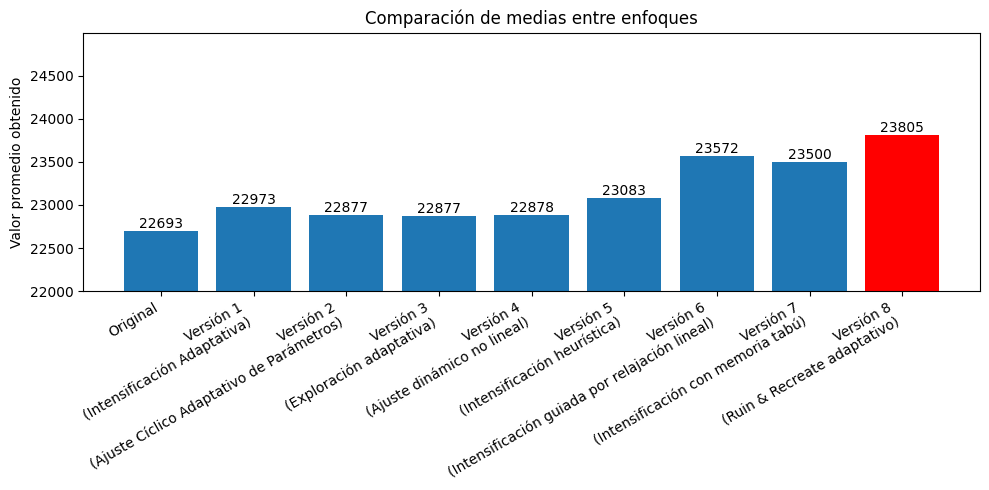

In [ ]:
import matplotlib.pyplot as plt
#con enfoque antiguo
# Medias ya calculadas
medias = [
    media_original,
    media_version1,
    media_version2,
    media_version3,
    media_version4,
    media_version5,
    media_version6,
    media_version7,
    media_version8
]

labels = [
    "Original",
    "Versión 1\n(Intensificación Adaptativa)",
    "Versión 2\n(Ajuste Cíclico Adaptativo de Parámetros)",
    "Versión 3\n(Exploración adaptativa)",
    "Versión 4\n(Ajuste dinámico no lineal)",
    "Versión 5\n(Intensificación heurística)",
    "Versión 6\n(Intensificación guiada por relajación lineal)",
    "Versión 7\n(Intensificación con memoria tabú)",
    "Versión 8\n(Ruin & Recreate adaptativo)"
]
colors = ["tab:blue"] * 8 + ["red"]

plt.figure(figsize=(10, 5))
plt.bar(labels, medias, color=colors)
plt.ylabel("Valor promedio obtenido")
plt.title("Comparación de medias entre enfoques")
plt.xticks(rotation=30, ha="right")
plt.ylim(bottom=22000)

plt.xticks(rotation=30, ha="right")

for i, v in enumerate(medias):
    plt.text(i, v, f"{v:.0f}", ha='center', va='bottom')
plt.tight_layout()
plt.show()


###Desviacion estandar

In [ ]:
resultados = [
    results_original,
    results_version1,
    results_version2,
    results_version3,
    results_version4,
    results_version5,
    results_version6,
    results_version7,
    results_version8
]

for label, data in zip(labels, resultados):
    std = np.std(data)
    print(f"{label}: desviación estándar = {std:.4f}")

Original: desviación estándar = 214.9926
Versión 1
(Intensificación Adaptativa): desviación estándar = 177.1814
Versión 2
(Ajuste Cíclico Adaptativo de Parámetros): desviación estándar = 238.3326
Versión 3
(Exploración adaptativa): desviación estándar = 222.7054
Versión 4
(Ajuste dinámico no lineal): desviación estándar = 205.0700
Versión 5
(Intensificación heurística): desviación estándar = 222.0361
Versión 6
(Intensificación guiada por relajación lineal): desviación estándar = 255.8785
Versión 7
(Intensificación con memoria tabú): desviación estándar = 284.5420
Versión 8
(Ruin & Recreate adaptativo): desviación estándar = 225.4084


/tmp/ipykernel_388/1680895124.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


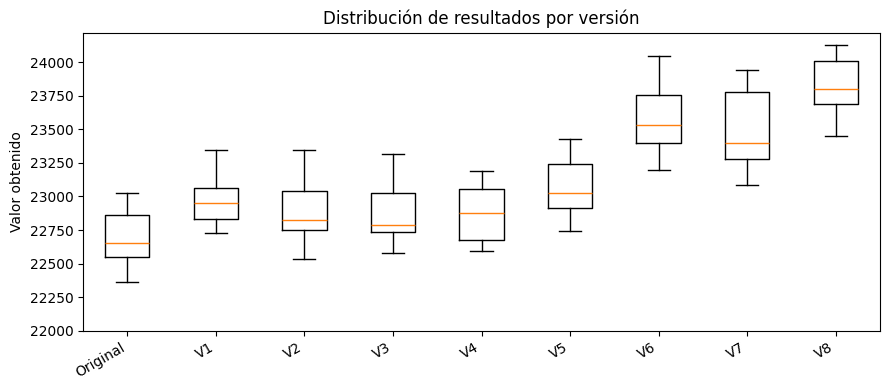

In [ ]:
plt.figure(figsize=(9,4))
plt.boxplot(
    [
        results_original,
        results_version1,
        results_version2,
        results_version3,
        results_version4,
        results_version5,
        results_version6,
        results_version7,
        results_version8
    ],
    labels= [
    "Original",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
    "V7",
    "V8"
],
    showfliers=True
)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Valor obtenido")
plt.title("Distribución de resultados por versión")
plt.ylim(bottom=22000)
plt.tight_layout()
plt.show()


###Wilcoxon

In [ ]:
from scipy.stats import wilcoxon

resultados = {
    "Original": results_original,
    "V1": results_version1,
    "V2": results_version2,
    "V3": results_version3,
    "V4": results_version4,
    "V5": results_version5,
    "V6": results_version6,
    "V7": results_version7,
    "V8": results_version8
}

for k, data in resultados.items():
    if k != "Original":
        stat, p = wilcoxon(data, results_original, alternative="greater")
        print(f"{k} vs Original -> p-value = {p:.5f}")

V1 vs Original -> p-value = 0.01855
V2 vs Original -> p-value = 0.06543
V3 vs Original -> p-value = 0.03223
V4 vs Original -> p-value = 0.02441
V5 vs Original -> p-value = 0.00195
V6 vs Original -> p-value = 0.00098
V7 vs Original -> p-value = 0.00098
V8 vs Original -> p-value = 0.00098
